In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import numpy as np
import os

csv_file = 'analitic_avito_dataset_50_pages.csv'

df = pd.read_csv(csv_file)

property_type_col = 'type'
space_col = 'space'
price_col = 'price'
area_price_col = 'area_price'
time_col = 'time_to_metro'
date_col = 'date'
link_col = 'link'
metro_col = 'metro'

def clean_currency_col(col):
    if col in df.columns and pd.api.types.is_string_dtype(df[col]):
        df[col] = df[col].str.replace(r'[^0-9]', '', regex=True).astype(float)

clean_currency_col(price_col)
clean_currency_col(area_price_col)

if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], format='%d.%m.%Y', errors='coerce')

if price_col in df.columns:
    Q1 = df[price_col].quantile(0.25)
    Q3 = df[price_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = max(0, Q1 - 1.5 * IQR)
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[price_col] >= lower_bound) & (df[price_col] <= upper_bound)]

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

if time_col in df.columns:
    time_min, time_max = df[time_col].min(), df[time_col].max()
    num_bins = 5
    bins = np.linspace(time_min, time_max, num_bins + 1)
    labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]
    df['time_bin'] = pd.cut(df[time_col], bins=bins, labels=labels, include_lowest=True)

output_dir = 'analysis_plots'
os.makedirs(output_dir, exist_ok=True)

In [97]:
if area_price_col in df.columns and space_col in df.columns and 'time_bin' in df.columns:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=space_col, y=area_price_col, hue='time_bin', palette='viridis', data=df)
    plt.title('Цена за м² в зависимости от площади (цвет по времени до метро)')
    plt.xlabel('Площадь')
    plt.ylabel('Цена за м²')
    plt.legend(title='Время до метро (мин)')
    plt.savefig(os.path.join(output_dir, 'scatter_price_vs_space.png'))
    plt.close()

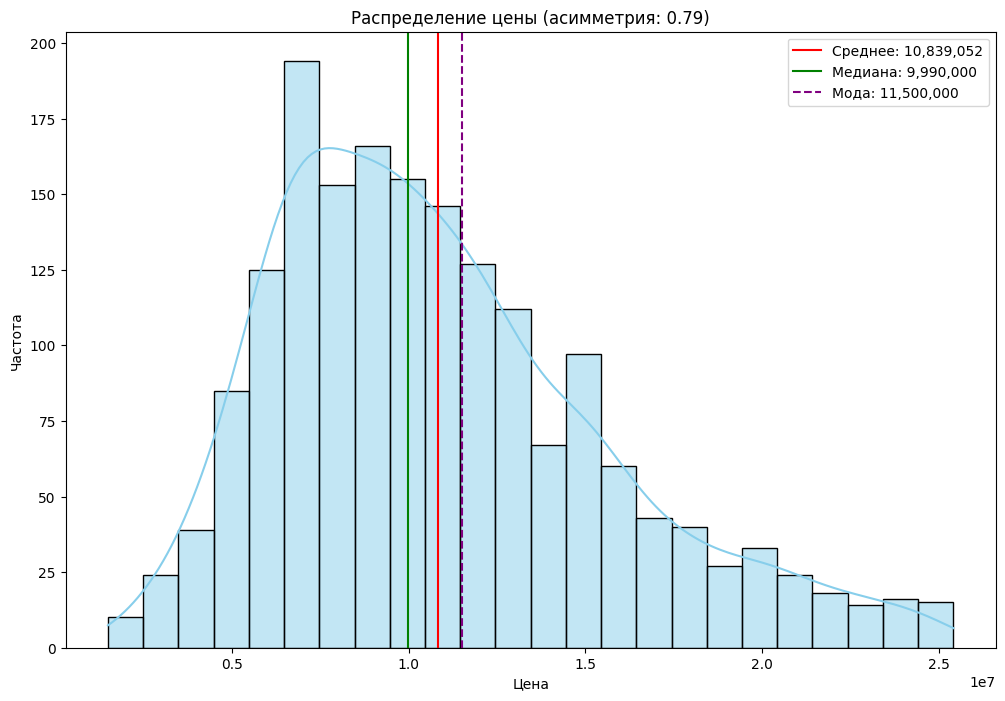

In [98]:
if price_col in df.columns:
    plt.figure(figsize=(12, 8))
    sns.histplot(df[price_col], kde=True, bins='auto', color='skyblue')
    mean_val = df[price_col].mean()
    median_val = df[price_col].median()
    mode_val = df[price_col].mode()[0] if not df[price_col].mode().empty else np.nan
    skewness_val = skew(df[price_col].dropna())

    plt.axvline(mean_val, color='red', linestyle='-', label=f'Среднее: {mean_val:,.0f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Медиана: {median_val:,.0f}')
    plt.axvline(mode_val, color='purple', linestyle='--', label=f'Мода: {mode_val:,.0f}')
    plt.title(f'Распределение цены (асимметрия: {skewness_val:.2f})')
    plt.xlabel('Цена')
    plt.ylabel('Частота')
    plt.legend()
    plt.savefig(os.path.join(output_dir, 'histogram_price.png'))
    plt.show()

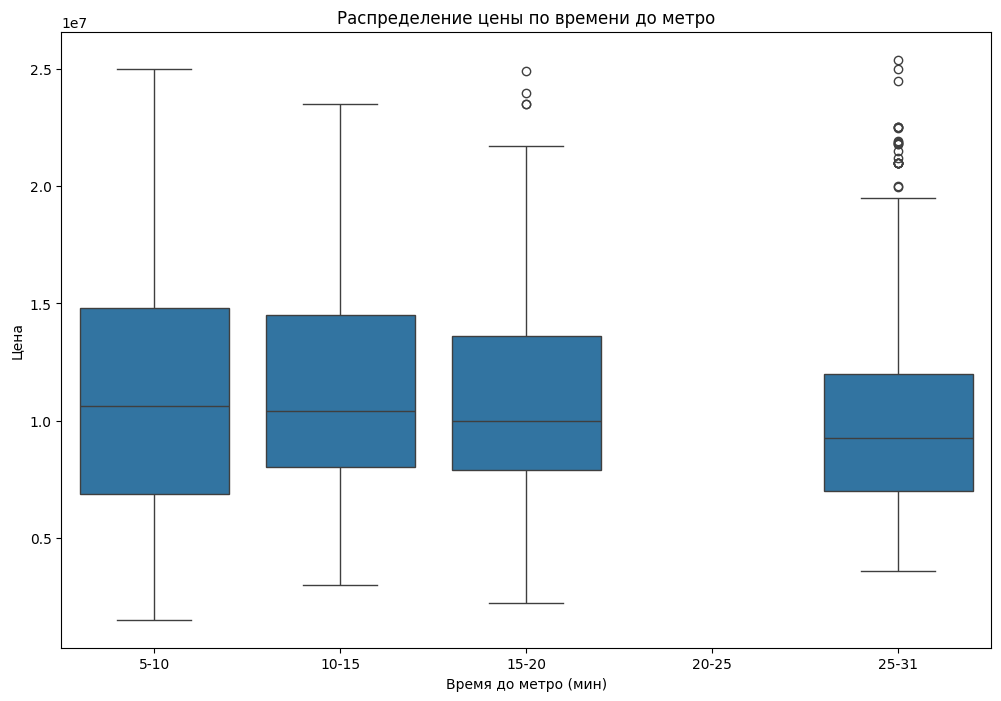

In [99]:
if price_col in df.columns and 'time_bin' in df.columns:
    plt.figure(figsize=(12, 8))
    sns.boxplot(x='time_bin', y=price_col, data=df)
    plt.title('Распределение цены по времени до метро')
    plt.xlabel('Время до метро (мин)')
    plt.ylabel('Цена')
    plt.savefig(os.path.join(output_dir, 'boxplot_price_by_time.png'))
    plt.show()

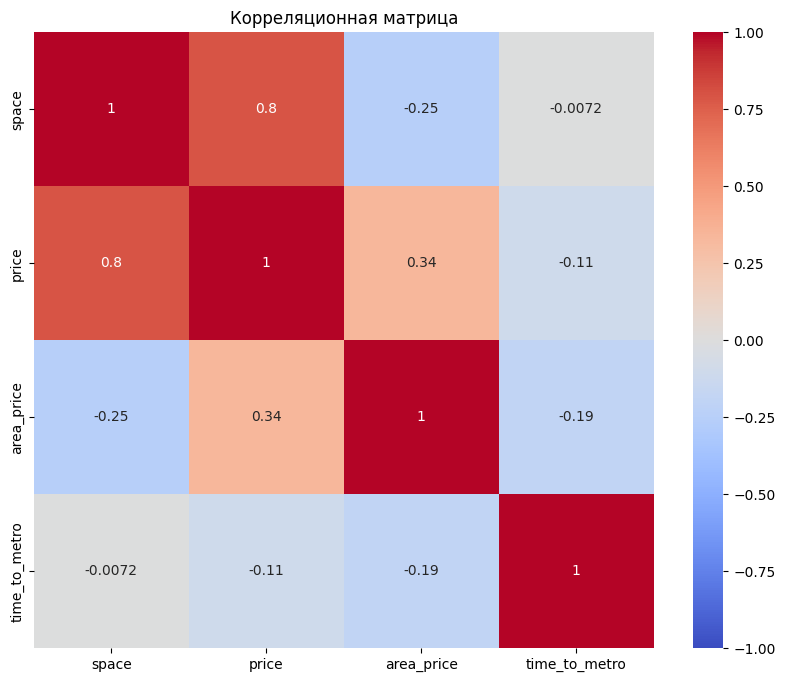

In [100]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Корреляционная матрица')
    plt.savefig(os.path.join(output_dir, 'correlation_matrix.png'))
    plt.show()

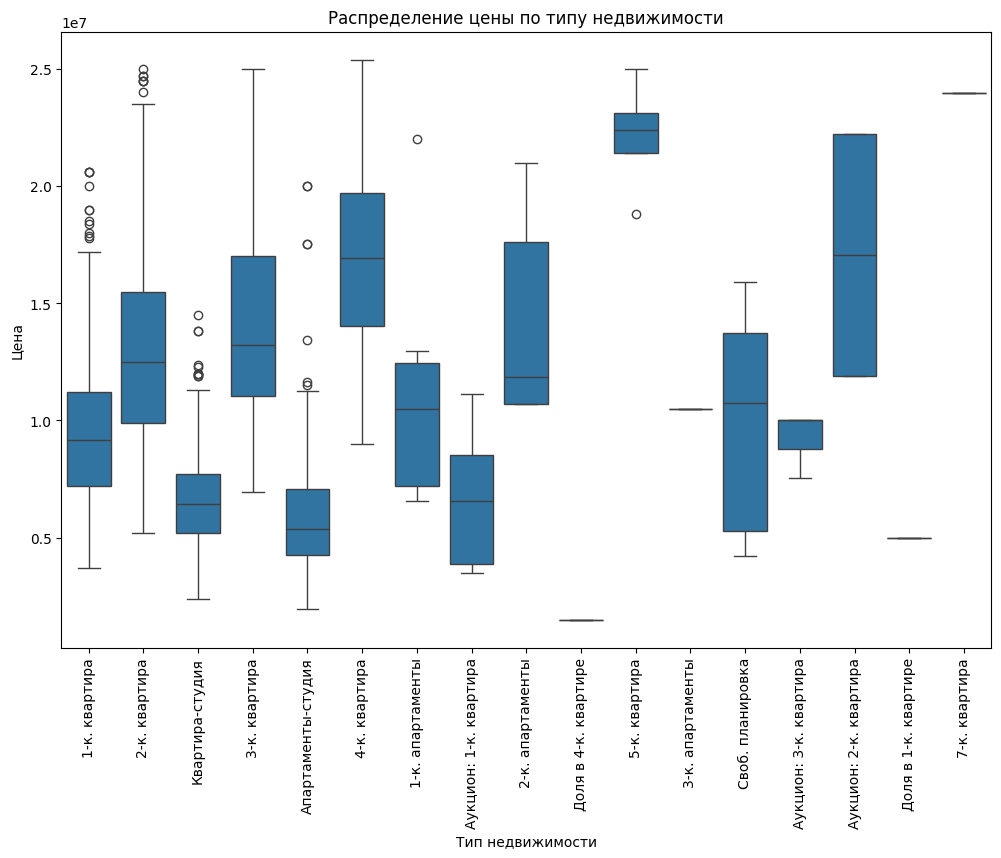

In [101]:
if price_col in df.columns and property_type_col in df.columns:
    plt.figure(figsize=(12, 8))
    sns.boxplot(x=property_type_col, y=price_col, data=df)
    plt.title('Распределение цены по типу недвижимости')
    plt.xlabel('Тип недвижимости')
    plt.ylabel('Цена')
    plt.xticks(rotation=90)
    plt.savefig(os.path.join(output_dir, 'boxplot_price_by_type.png'))
    plt.show()

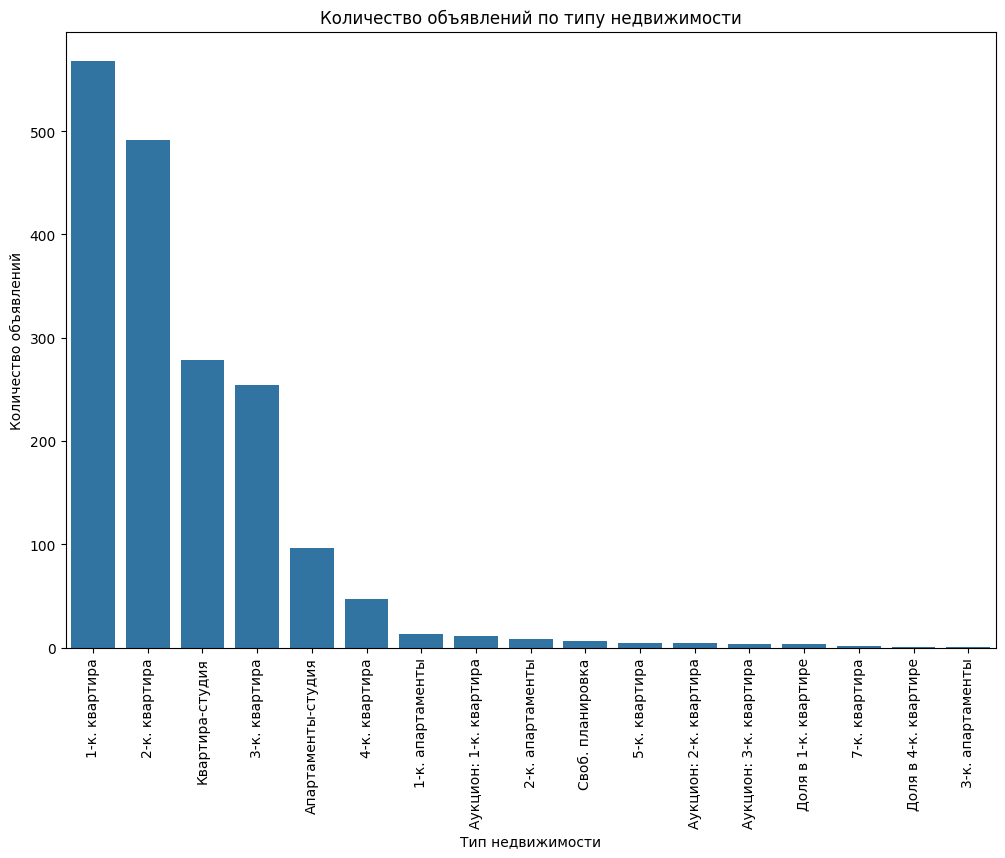

In [102]:
###NEW

if property_type_col in df.columns:
    plt.figure(figsize=(12, 8))
    sns.countplot(x=property_type_col, data=df, order=df[property_type_col].value_counts().index)
    plt.title('Количество объявлений по типу недвижимости')
    plt.xlabel('Тип недвижимости')
    plt.ylabel('Количество объявлений')
    plt.xticks(rotation=90)
    plt.savefig(os.path.join(output_dir, 'countplot_by_type.png'))
    plt.show()

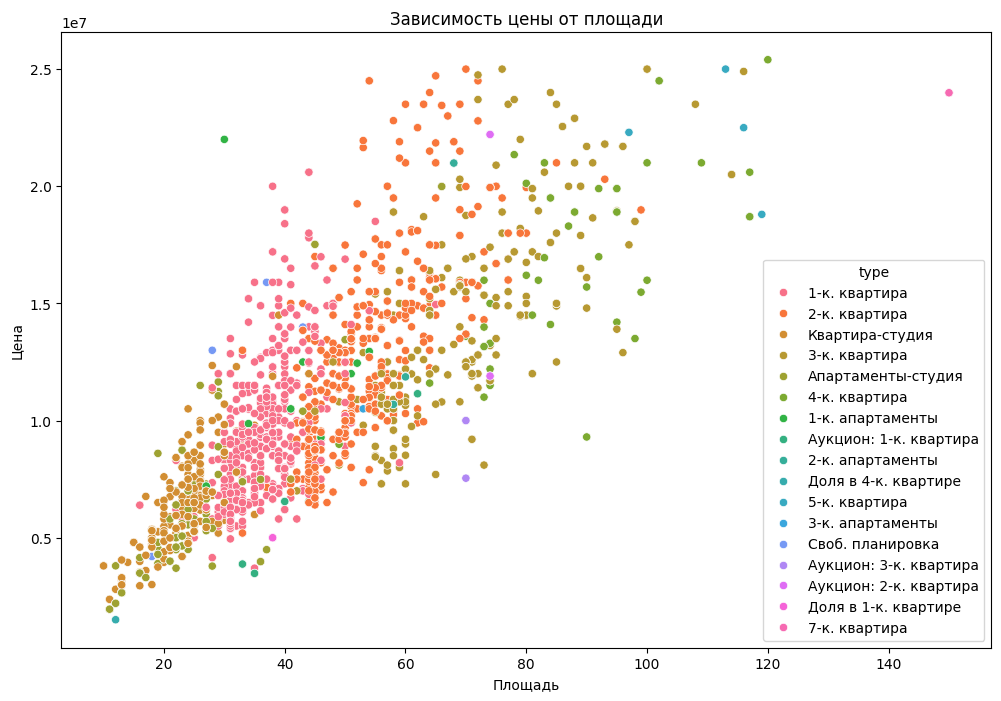

In [103]:
if space_col in df.columns and price_col in df.columns and property_type_col in df.columns:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=space_col, y=price_col,hue=property_type_col, data=df)
    plt.title('Зависимость цены от площади')
    plt.xlabel('Площадь')
    plt.ylabel('Цена')
    plt.xticks()
    plt.savefig(os.path.join(output_dir, 'scatterplot_price_by_area.png'))
    plt.show()

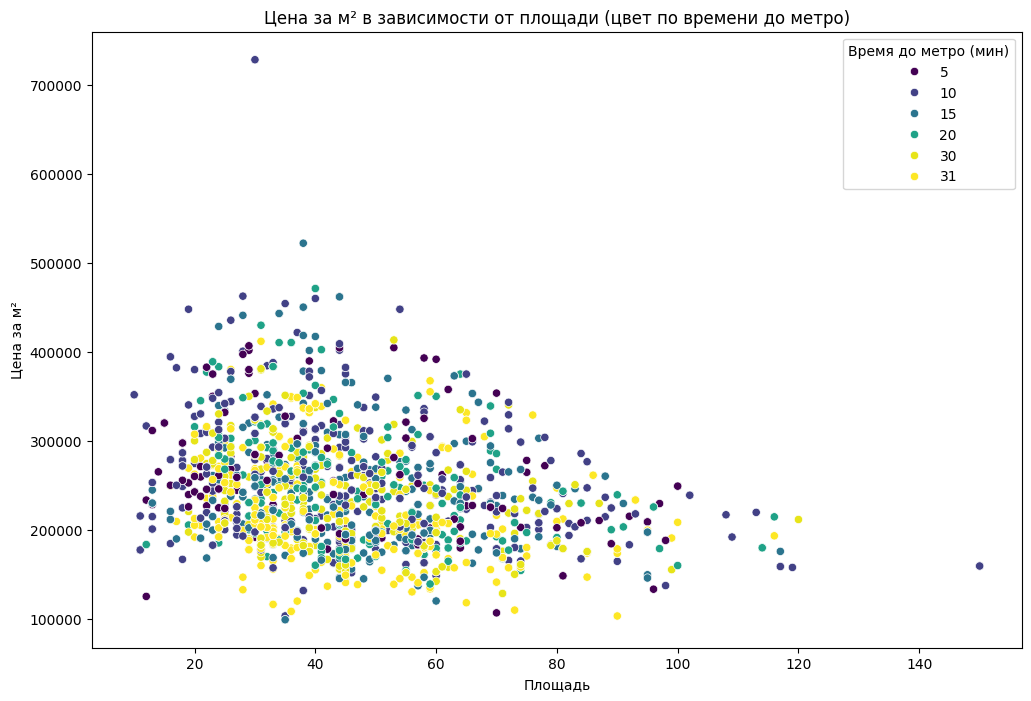

In [112]:
if area_price_col in df.columns and space_col in df.columns and time_col in df.columns:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=space_col, y=area_price_col, hue=time_col, palette='viridis', data=df)
    plt.title('Цена за м² в зависимости от площади (цвет по времени до метро)')
    plt.xlabel('Площадь')
    plt.ylabel('Цена за м²')
    plt.legend(title='Время до метро (мин)')
    plt.savefig(os.path.join(output_dir, 'scatter_price_per_area_by_time.png'))
    plt.show()

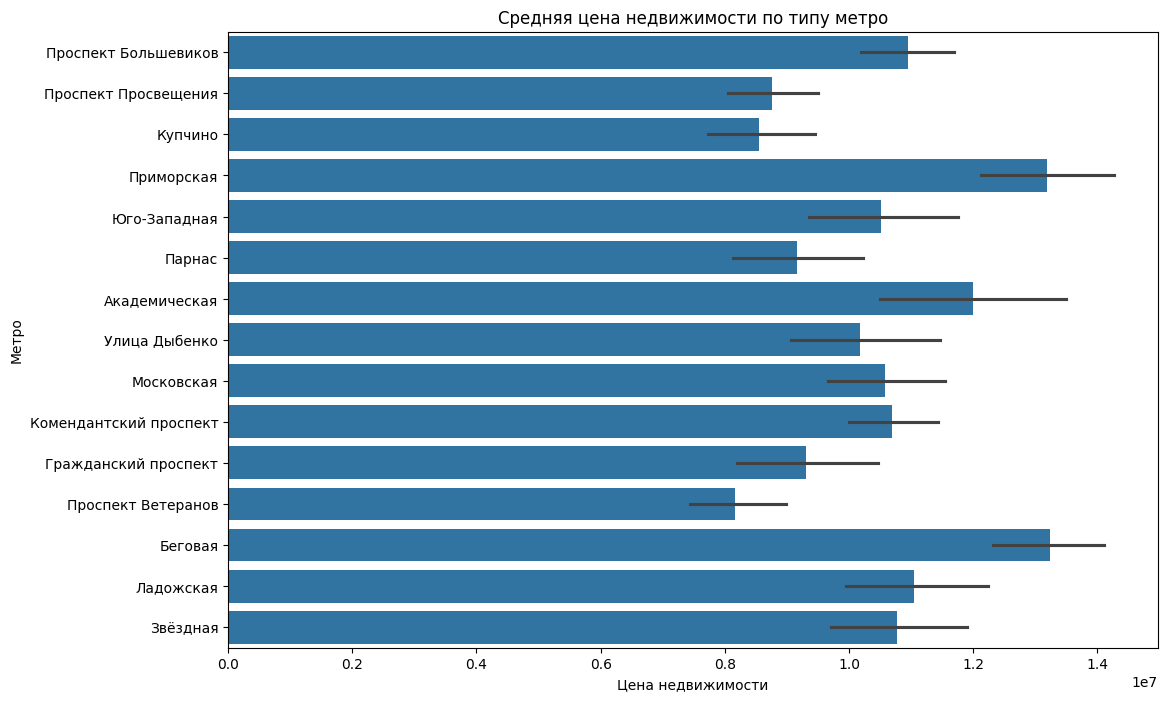

In [104]:
if metro_col in df.columns and price_col in df.columns:
    #топ 15 метро
    top_metros= df[metro_col].value_counts().head(15).index
    plt.figure(figsize=(12, 8))
    sns.barplot(x=price_col, y=metro_col, data=df[df[metro_col].isin(top_metros)], estimator=np.mean)
    plt.title('Средняя цена недвижимости по типу метро')
    plt.xlabel('Цена недвижимости')
    plt.ylabel('Метро')
    plt.xticks()
    plt.savefig(os.path.join(output_dir, 'vertical_barplot.png'))
    plt.show()

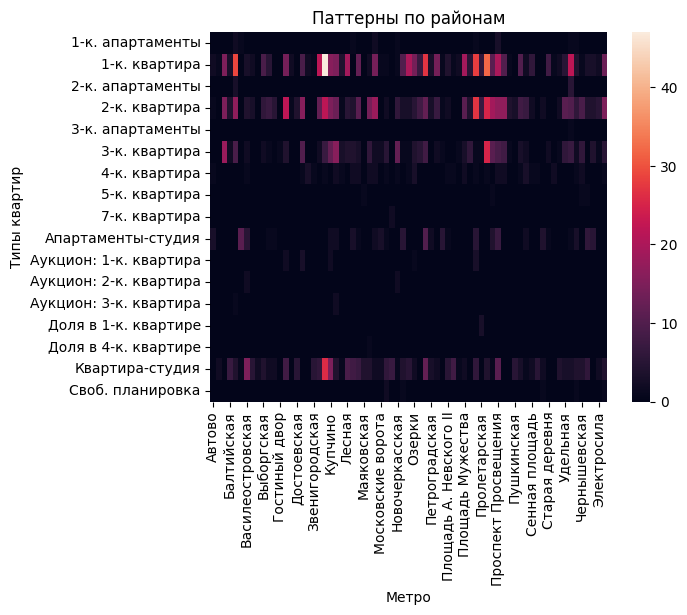

In [105]:
if metro_col in df.columns and property_type_col in df.columns:
    ct=pd.crosstab(df[property_type_col], df[metro_col])
    sns.heatmap(ct, annot=False, fmt='d')
    plt.title('Паттерны по районам')
    plt.ylabel('Типы квартир')
    plt.xlabel('Метро')
    plt.xticks()
    plt.savefig(os.path.join(output_dir, 'heatmap.png'))
    plt.show()

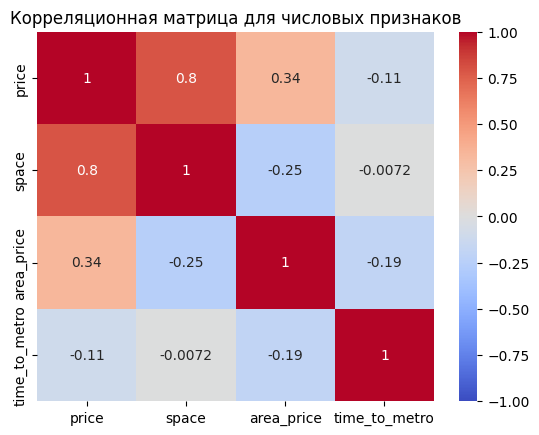

In [106]:
#Уже было

if price_col in df.columns and space_col in df.columns and area_price_col in df.columns and time_col in df.columns:
    num_cols=[price_col, space_col, area_price_col, time_col]
    sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Корреляционная матрица для числовых признаков')
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks()
    plt.yticks()
    plt.savefig(os.path.join(output_dir, 'correlation_matrix_numeric.png'))
    plt.show()

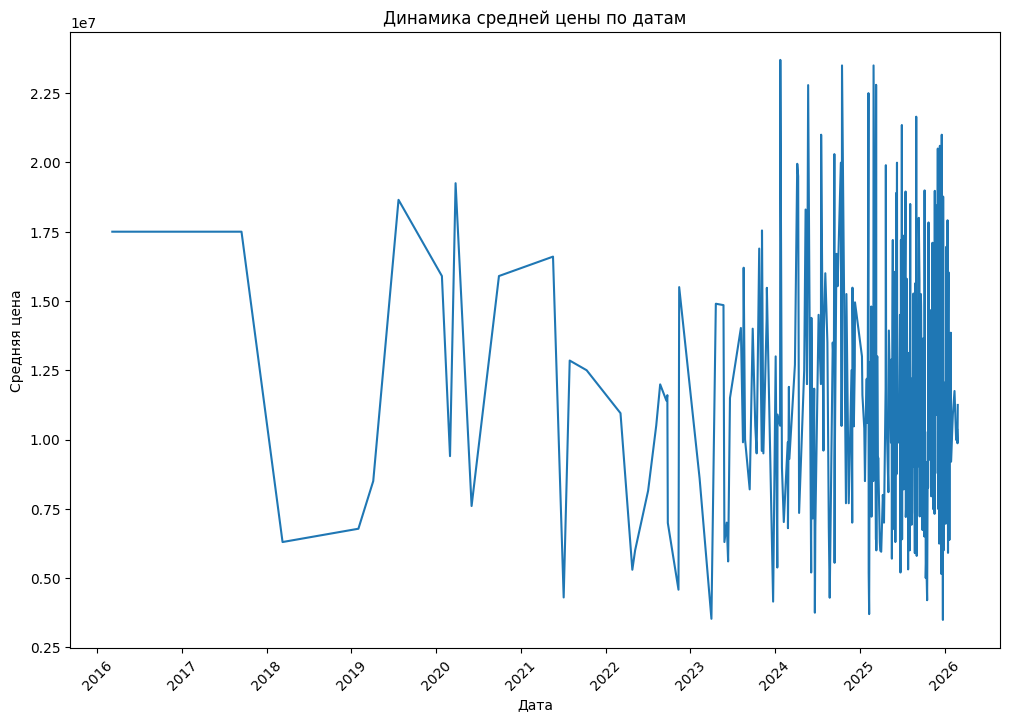

In [107]:
if date_col in df.columns and price_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col])
    df_time=df.groupby(date_col)[price_col].mean().reset_index()
    plt.figure(figsize=(12, 8))
    # df_time.set_index(date_col)[price_col].plot()
    sns.lineplot(x=date_col, y=price_col, data=df_time)
    plt.title('Динамика средней цены по датам')
    plt.xlabel('Дата')
    plt.ylabel('Средняя цена')
    plt.xticks(rotation=45)
    plt.savefig(os.path.join(output_dir, 'lineplot_price_over_time.png'))
    plt.show()

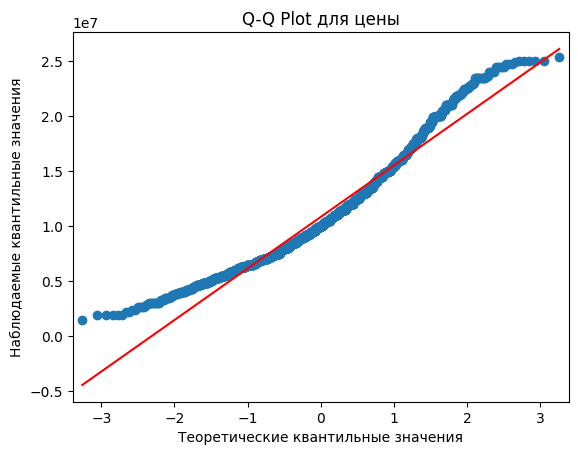

In [108]:
import statsmodels.api as sm

if price_col in df.columns:
    sm.qqplot(df[price_col], line='s')
    plt.title('Q-Q Plot для цены')
    plt.xlabel('Теоретические квантильные значения')
    plt.ylabel('Наблюдаемые квантильные значения')
    plt.xticks()
    plt.yticks()
    plt.savefig(os.path.join(output_dir, 'qqplot_price.png'))
    plt.show()


<Axes: >

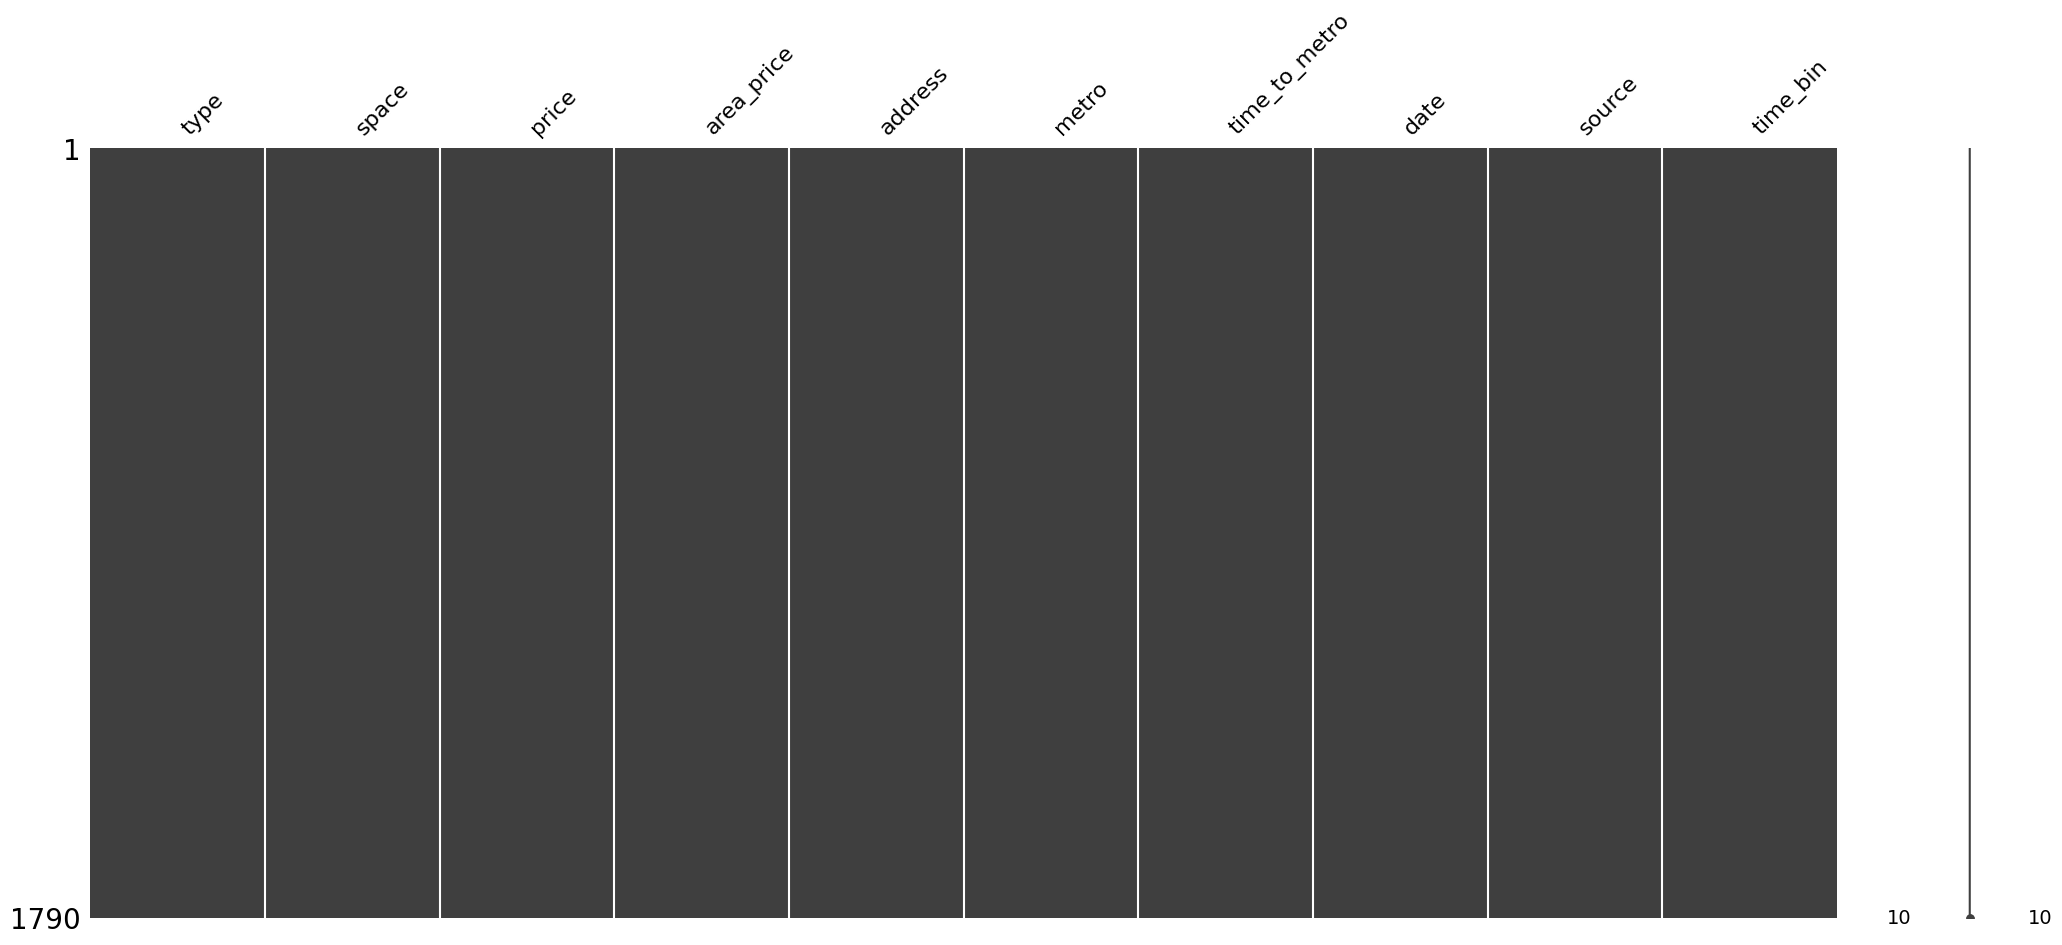

In [109]:
import missingno as msno

msno.matrix(df)



In [ ]:
import plotly.express as px

if space_col in df.columns and price_col in df.columns and property_type_col in df.columns and metro_col in df.columns:
    fig=px.scatter(df, x=space_col, y=price_col, color=property_type_col, title='Зависимость цены от площади с цветом по типу недвижимости')
    fig.show(renderer='browser')

In [111]:
for col in [price_col, area_price_col]:
    if col in df.columns:
        data = df[col].dropna()
        skewness = skew(data)
        kurt = kurtosis(data)  # Fisher (excess kurtosis, нормаль = 0)
        print(f'Асимметрия {col}: {skewness:.2f}')
        print(f'Эксцесс {col}: {kurt:.2f}')

print(f'Графики сохранены в директории: {output_dir}')

Асимметрия price: 0.79
Эксцесс price: 0.25
Асимметрия area_price: 1.00
Эксцесс area_price: 2.40
Графики сохранены в директории: analysis_plots
